<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/10_text_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analysis

In [1]:
import nltk

In [32]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('genesis')

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')
nltk.download('tagsets_json')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package genesis to /root/nltk_data...
[nltk_data]   Unzipping corpora/genesis.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


True

In [22]:
import string

import polars as pl
import pandas as pd

from nltk.corpus import stopwords, wordnet
from nltk.text import TextCollection
from nltk.stem import (
    PorterStemmer,
    LancasterStemmer,
    RegexpStemmer,
    SnowballStemmer,
    WordNetLemmatizer as wnl,
)

from nltk.tokenize.treebank import (
    TreebankWordDetokenizer,
    TreebankWordTokenizer
)
from nltk.tag import pos_tag

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer,
)

In [4]:
stop_words = set(stopwords.words('english'))
porter = PorterStemmer()
lancaster = LancasterStemmer()
snowball = SnowballStemmer('english')
regexp = RegexpStemmer('ing$|s$|e$|able$', min=4)
lemmatizer = wnl()

### Stemming: Comparing NLTK Stemmers

In [5]:
tokens_to_process = ['package', 'comfort-fit', 'running', 'shoes', 'arrived', 'damaged']
filtered_tokens = pl.DataFrame(
    {
        "tokens": [
            word for word in tokens_to_process
            if word.lower() not in stop_words
            ]
    }
    )
filtered_tokens = filtered_tokens.with_columns(
    pl.col("tokens").map_elements(
      porter.stem, return_dtype=pl.String).alias("porter_stemmed"),
    pl.col("tokens").map_elements(
      lancaster.stem, return_dtype=pl.String).alias("lancaster_stemmed"),
    pl.col("tokens").map_elements(
      snowball.stem, return_dtype=pl.String).alias("snowball_stemmed"),
)

display(filtered_tokens)

tokens,porter_stemmed,lancaster_stemmed,snowball_stemmed
str,str,str,str
"""package""","""packag""","""pack""","""packag"""
"""comfort-fit""","""comfort-fit""","""comfort-fit""","""comfort-fit"""
"""running""","""run""","""run""","""run"""
"""shoes""","""shoe""","""sho""","""shoe"""
"""arrived""","""arriv""","""ar""","""arriv"""
"""damaged""","""damag""","""dam""","""damag"""


### POS Tagging

In [6]:
tokens_to_process = nltk.word_tokenize("They refuse to permit us to obtain the refuse permit")
tagged_tokens = pl.DataFrame(
    pos_tag(tokens_to_process, tagset='universal'),
    schema=["token", "universal_pos_tag"],
    orient="row").join(
    pl.DataFrame(
        pos_tag(tokens_to_process),
        schema=["token", "penn_treebank"],
        orient="row"), on="token")
tagged_tokens

token,universal_pos_tag,penn_treebank
str,str,str
"""They""","""PRON""","""PRP"""
"""refuse""","""VERB""","""VBP"""
"""refuse""","""NOUN""","""VBP"""
"""to""","""PRT""","""TO"""
"""to""","""PRT""","""TO"""
…,…,…
"""the""","""DET""","""DT"""
"""refuse""","""VERB""","""NN"""
"""refuse""","""NOUN""","""NN"""


### Mapping Tags

In [7]:
def get_wordnet_pos(treebank_tag):
   """
   Maps Treebank POS tags to WordNet POS tags.
   """
   if treebank_tag.startswith('J'):
       return wordnet.ADJ
   elif treebank_tag.startswith('V'):
       return wordnet.VERB
   elif treebank_tag.startswith('N'):
       return wordnet.NOUN
   elif treebank_tag.startswith('R'):
       return wordnet.ADV
   else:
       # As a default, assume noun if the tag is not recognized
       return wordnet.NOUN

### Lemmatization Example

In [8]:
sentence = "The children are running and playing in the beautiful gardens"
# 1. Tokenize sentence
tokens = nltk.word_tokenize(sentence)
# 2. Tag the tokens
tagged_tokens = pos_tag(nltk.word_tokenize(sentence))
# 3. Filter the stop words
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
# 4. Lemmatize the tokens using POS tags
# Stop words are not skipped here just for demonstration
lemmas = [
    lemmatizer.lemmatize(token, get_wordnet_pos(tag))
    for token, tag in tagged_tokens
    # for token, tag in pos_tag(filtered_tokens)
]
print("Tokens: ")
print(tokens)
print("Filtered Tokens: ")
print(filtered_tokens)
print("Lemmas: ")
print(lemmas)
print("Filtered Lemmas: ")
print(list(lemma for lemma in lemmas if lemma.lower() not in stop_words))

pl.DataFrame({
    "token": tokens ,
    "lemma": lemmas,
    "is_stop_words": [word.lower() in stop_words for word in nltk.word_tokenize(sentence)],
    })

Tokens: 
['The', 'children', 'are', 'running', 'and', 'playing', 'in', 'the', 'beautiful', 'gardens']
Filtered Tokens: 
['children', 'running', 'playing', 'beautiful', 'gardens']
Lemmas: 
['The', 'child', 'be', 'run', 'and', 'play', 'in', 'the', 'beautiful', 'garden']
Filtered Lemmas: 
['child', 'run', 'play', 'beautiful', 'garden']


token,lemma,is_stop_words
str,str,bool
"""The""","""The""",true
"""children""","""child""",false
"""are""","""be""",true
"""running""","""run""",false
"""and""","""and""",true
"""playing""","""play""",false
"""in""","""in""",true
"""the""","""the""",true
"""beautiful""","""beautiful""",false


## Text Data Preparation Example

In [9]:
df = pl.read_csv("/content/global-cart.csv")
for idx, comment in enumerate(df['FeedbackText']):
  print(f"{idx+1}. {comment}\n")

1. The Pro-Grade Blender is a beast! It's powerful and quiet. Delivery was also incredibly fast, arrived in one day.

2. My package with the Comfort-Fit Running Shoes arrived damaged, and the box was completely crushed. Disappointed.

3. I had to return the blender. It was much larger than expected and didn't fit on my counter. The return was easy.

4. Are the Comfort-Fit shoes waterproof? Need to know before I buy. Your support chat is offline.

5. Fast shipping is great, but the Pro-Grade Blender's lid doesn't seem to seal properly. Seems like a defect.



In [10]:
def prep_doc(
    doc,
    *,
    tokenizer=None,
    lemmatizer=None,
    stemmer=None,
    exclude_stop_words=True,
):
    """Tokenizes, filters, and processes a text document.

    This function takes a raw text string and performs a series of NLP
    preprocessing steps, including tokenization, optional stop word removal,
    optional lemmatization, and optional stemming.

    Args:
        doc (str): The input text document to process.
        lemmatizer (object, optional): An initialized lemmatizer object with a
            `.lemmatize()` method (e.g., from NLTK). Defaults to None.
        stemmer (object, optional): An initialized stemmer object with a
            `.stem()` method (e.g., from NLTK). Defaults to None.
        exclude_stop_words (bool, optional): If True, removes common English
            stop words from the token list. Defaults to True.

    Returns:
        dict: A dictionary containing the results of the processing steps.
            The keys are:
            - "tokens" (list): The original tokens from the document.
            - "filtered_tokens" (list): Tokens after stop word removal (if enabled).
            - "lemmas" (list or None): The lemmatized version of the
              filtered tokens. None if no lemmatizer is provided.
            - "stemmed_tokens" (list or None): The stemmed version of the
              filtered tokens. None if no stemmer is provided.
    """
    if not tokenizer:
        tokenizer = nltk.word_tokenize
    tokens = tokenizer(doc)
    punctuation = set(string.punctuation)
    stop_words = set(stopwords.words('english'))

    filtered_tokens = tokens
    lemmas = None
    stemmed_tokens = None

    if exclude_stop_words:
        filtered_tokens = []
        for token in tokens:
          if token.lower() not in stop_words and token not in punctuation:
            filtered_tokens.append(token.lower())

    if lemmatizer:
        lemmas = [
          lemmatizer.lemmatize(token, get_wordnet_pos(tag))
          for token, tag in pos_tag(filtered_tokens)
        ]

    if stemmer:
        stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]

    return {
        "tokens": tokens,
        "filtered_tokens": filtered_tokens,
        "lemmas": lemmas,
        "stemmed_tokens": stemmed_tokens,
    }

In [11]:
def my_tokenizer(doc):
  tokenizer = TreebankWordTokenizer()
  sentences = nltk.sent_tokenize(doc)
  return [
      token
      for sent in sentences
      for token in tokenizer.tokenize(sent)
  ]

In [20]:
feedback_corpus = df.select(pl.col('FeedbackText')).to_series().to_list()
detokenizer = TreebankWordDetokenizer()
processed_corpus = [
    detokenizer.detokenize(
        prep_doc(
            doc,
            exclude_stop_words=False,
            tokenizer=my_tokenizer,
            lemmatizer=lemmatizer,
            stemmer=porter)["lemmas"]
        )
    for doc in feedback_corpus
 ]

processed_corpus

["The Pro-Grade Blender be a beast! It's powerful and quiet . Delivery be also incredibly fast, arrive in one day.",
 'My package with the Comfort-Fit Running Shoes arrive damage, and the box be completely crush . Disappointed.',
 "I have to return the blender . It be much large than expect and don't fit on my counter . The return be easy.",
 'Are the Comfort-Fit shoe waterproof? Need to know before I buy . Your support chat be offline.',
 "Fast shipping be great, but the Pro-Grade Blender's lid don't seem to seal properly . Seems like a defect."]

In [23]:
vectorizer = CountVectorizer()

document_term_matrix = vectorizer.fit_transform(processed_corpus)

vocabulary = vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(document_term_matrix.toarray(), columns=vocabulary)

print("Vocabulary:", vocabulary)

Vocabulary: ['also' 'and' 'are' 'arrive' 'be' 'beast' 'before' 'blender' 'box' 'but'
 'buy' 'chat' 'comfort' 'completely' 'counter' 'crush' 'damage' 'day'
 'defect' 'delivery' 'disappointed' 'don' 'easy' 'expect' 'fast' 'fit'
 'grade' 'great' 'have' 'in' 'incredibly' 'it' 'know' 'large' 'lid' 'like'
 'much' 'my' 'need' 'offline' 'on' 'one' 'package' 'powerful' 'pro'
 'properly' 'quiet' 'return' 'running' 'seal' 'seem' 'seems' 'shipping'
 'shoe' 'shoes' 'support' 'than' 'the' 'to' 'waterproof' 'with' 'your']


In [24]:
df_bow

,also,and,are,arrive,be,beast,before,blender,box,but,...,shipping,shoe,shoes,support,than,the,to,waterproof,with,your
0,1,1,0,1,2,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,1,0,1,1,0,0,0,1,0,...,0,0,1,0,0,2,0,0,1,0
2,0,1,0,0,2,0,0,1,0,0,...,0,0,0,0,1,2,1,0,0,0
3,0,0,1,0,1,0,1,0,0,0,...,0,1,0,1,0,1,1,1,0,1
4,0,0,0,0,1,0,0,1,0,1,...,1,0,0,0,0,1,1,0,0,0


In [25]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(processed_corpus)

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [26]:
df_tfidf

,also,and,are,arrive,be,beast,before,blender,box,but,...,shipping,shoe,shoes,support,than,the,to,waterproof,with,your
0,0.264564,0.177182,0.000000,0.213449,0.252133,0.264564,0.000000,0.177182,0.00000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.126066,0.000000,0.000000,0.00000,0.000000
1,0.000000,0.185851,0.000000,0.223893,0.132235,0.000000,0.000000,0.000000,0.27751,0.000000,...,0.000000,0.000000,0.27751,0.000000,0.000000,0.264470,0.000000,0.000000,0.27751,0.000000
2,0.000000,0.159803,0.000000,0.000000,0.227402,0.000000,0.000000,0.159803,0.00000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.238615,0.227402,0.159803,0.000000,0.00000,0.000000
3,0.000000,0.000000,0.277328,0.000000,0.132148,0.000000,0.277328,0.000000,0.00000,0.000000,...,0.000000,0.277328,0.00000,0.277328,0.000000,0.132148,0.185730,0.277328,0.00000,0.277328
4,0.000000,0.000000,0.000000,0.000000,0.127557,0.000000,0.000000,0.179278,0.00000,0.267694,...,0.267694,0.000000,0.00000,0.000000,0.000000,0.127557,0.179278,0.000000,0.00000,0.000000


In [35]:
bigram_measures = nltk.collocations.BigramAssocMeasures()
trigram_measures = nltk.collocations.TrigramAssocMeasures()
fourgram_measures = nltk.collocations.QuadgramAssocMeasures()
finder = nltk.collocations.BigramCollocationFinder.from_words(
    nltk.corpus.genesis.words('english-web.txt'))
finder.nbest(bigram_measures.pmi, 10)

[('Allon', 'Bacuth'),
 ('Ashteroth', 'Karnaim'),
 ('Ben', 'Ammi'),
 ('En', 'Mishpat'),
 ('Jegar', 'Sahadutha'),
 ('Salt', 'Sea'),
 ('Whoever', 'sheds'),
 ('appoint', 'overseers'),
 ('aromatic', 'resin'),
 ('cutting', 'instrument')]

<Axes: xlabel='Samples', ylabel='Counts'>

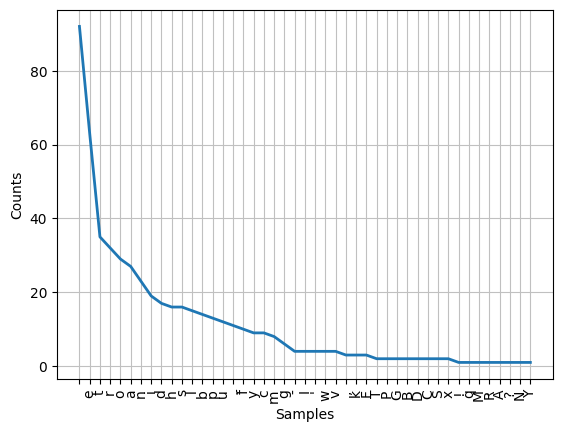

In [40]:
feedback = TextCollection(processed_corpus)
feedback.plot()
# len(nltk.corpus.genesis.words('english-web.txt'))